In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
import warnings
import joblib

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv('/content/sample_data/Cyber_salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M


# Understanding Cyber salaries Data

In [3]:
# Shape of Data
df.shape

(1349, 11)

Cyber Salaries dataset has 1349 samples (rows) and 11 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           1349 non-null   int64 
 1   experience_level    1349 non-null   object
 2   employment_type     1349 non-null   object
 3   job_title           1349 non-null   object
 4   salary              1349 non-null   int64 
 5   salary_currency     1349 non-null   object
 6   salary_in_usd       1349 non-null   int64 
 7   employee_residence  1349 non-null   object
 8   remote_ratio        1349 non-null   int64 
 9   company_location    1349 non-null   object
 10  company_size        1349 non-null   object
dtypes: int64(4), object(7)
memory usage: 116.1+ KB


The Cyber salary dataset comprises of four integer (int64) columns and seven object (string) columns. Additionally, it has small memory size with no missing values, as all columns have identical record counts.

In [5]:
# Descriptive statistics analysis
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,1349.000000,1.349000e+03,1349.000000,1349.000000
mean,2021.368421,5.288248e+05,121578.622683,72.238695
std,0.711236,1.361367e+07,68972.954838,39.355331
min,2020.000000,1.740000e+03,2000.000000,0.000000
25%,2021.000000,8.000000e+04,75000.000000,50.000000
50%,2022.000000,1.200000e+05,115000.000000,100.000000
75%,2022.000000,1.600800e+05,152000.000000,100.000000
max,2022.000000,5.000000e+08,899920.000000,100.000000


From the above statistical summary, we can draw sum insights:
- Minimum Cyber Security Salary is 2000 USD
- Maximum Cyber Security Salary is 899920 USD
- This dataset is based from 2020 to 2022

In [6]:
# Descriptive Statistical Analysis to all columns
df.describe(include='all')

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,1349.000000,1349,1349,1349,1.349000e+03,1349,1349.000000,1349,1349.000000,1349,1349
unique,NaN,4,4,87,NaN,21,NaN,60,NaN,57,3
top,NaN,SE,FT,Security Engineer,NaN,USD,NaN,US,NaN,US,L
freq,NaN,622,1326,247,NaN,1026,NaN,940,NaN,965,798
mean,2021.368421,NaN,NaN,NaN,5.288248e+05,NaN,121578.622683,NaN,72.238695,NaN,NaN
std,0.711236,NaN,NaN,NaN,1.361367e+07,NaN,68972.954838,NaN,39.355331,NaN,NaN
min,2020.000000,NaN,NaN,NaN,1.740000e+03,NaN,2000.000000,NaN,0.000000,NaN,NaN
25%,2021.000000,NaN,NaN,NaN,8.000000e+04,NaN,75000.000000,NaN,50.000000,NaN,NaN
50%,2022.000000,NaN,NaN,NaN,1.200000e+05,NaN,115000.000000,NaN,100.000000,NaN,NaN
75%,2022.000000,NaN,NaN,NaN,1.600800e+05,NaN,152000.000000,NaN,100.000000,NaN,NaN


__Other Insight__

- In the cybersecurity field, the majority of professionals are employed in the role of Security Engineer. However, this observation cannot be generalized across all countries, as 64% (860 samples) of the cybersecurity salaries dataset originates from the United States.

In [7]:
# Check number of unique job titles and their locations
jobs = df['job_title'].unique()
location = df['company_location'].unique()

print(f'There are',len(jobs), f'unique job titles from',len(location), f'countries.')

There are 87 unique job titles from 57 countries.


Cyber Salaries dataset has 87 unique job titles from 57 countries around the world. This demonstrate a broad range of specialization areas within the security domain and providing valuable insight for security professionals when identifying or selecting areas of focus.

# Data Cleaning

In [8]:
# Missing values
df.isna().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


No missing values in this dataset

In [9]:
# Duplicate values
df.duplicated().sum()

np.int64(115)

There are 115 duplicate values in Cyber salaries dataset

In [10]:
# Handling duplicate values
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(1234, 11)

The removal of duplicate values resulted in a reduction of the dataset to 1,234 samples.

# Exploratory Data Analysis (EDA)

__Correlation on Numerical features__

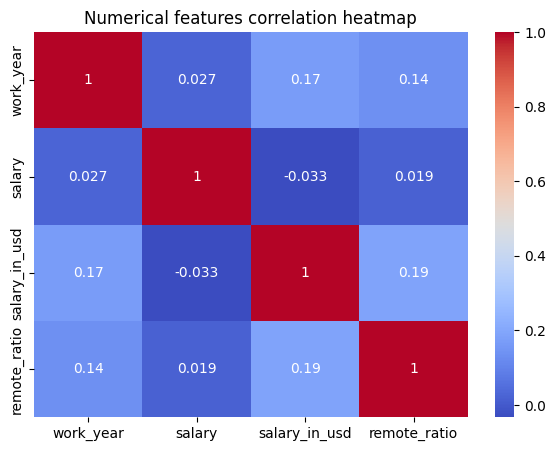

In [12]:
numeric_cols = df.select_dtypes(include=['int64'])

# correlation heatmap
plt.figure(figsize=(7,5))
cor = numeric_cols.corr()
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.title('Numerical features correlation heatmap')
plt.show()

The correlation heatmap shows positive relationship between remote_ratio and salary_in_usd. This implies the higher the percentage of work done remotely by employee can increase the salary.

<h3>Does company size impact the salary of a cybersecurity employee?</h3>

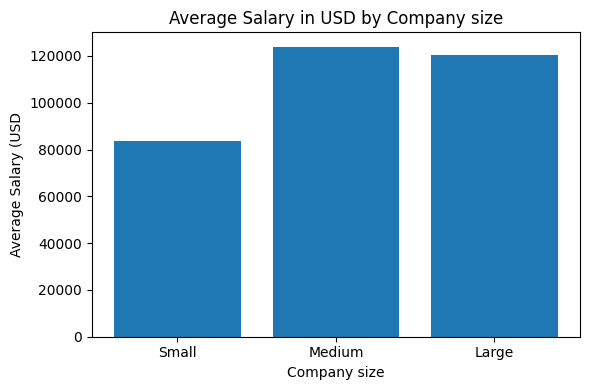

In [13]:
sizes = {'S':'Small', 'M':'Medium', 'L':'Large'}
avg_salary = (df.groupby('company_size')['salary_in_usd'].mean().reset_index())

# replace company sizes eg.S -> Small
avg_salary['company_size'] = (avg_salary['company_size'].map(sizes))

order = ['Small', 'Medium', 'Large']
# convert 'company_size' into a ordered categorical variable
avg_salary['company_size'] = pd.Categorical(avg_salary['company_size'], categories=order, ordered=True) # define logical order for a column
avg_salary = avg_salary.sort_values('company_size')

#plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(avg_salary['company_size'], avg_salary['salary_in_usd'])
plt.title('Average Salary in USD by Company size')
plt.xlabel('Company size')
plt.ylabel('Average Salary (USD')
plt.tight_layout() # adjusts spacing between plot elements to avoid overlapping of labels, titles and axes
plt.show()

In [14]:
avg_salary

,company_size,salary_in_usd
2,Small,83625.228261
1,Medium,123916.445652
0,Large,120620.540052


The analysis above suggests that company size alone cannot determine whether an individual will receive higher or lower pay. Due to the average salary from company size, people employed in medium-sized companies may be more likely to receive higher pay than those in large and small companies, but this is an analysis based on the collected data.

<h3>Does level of experience impact the salary of cybersecurity employee?</h3>

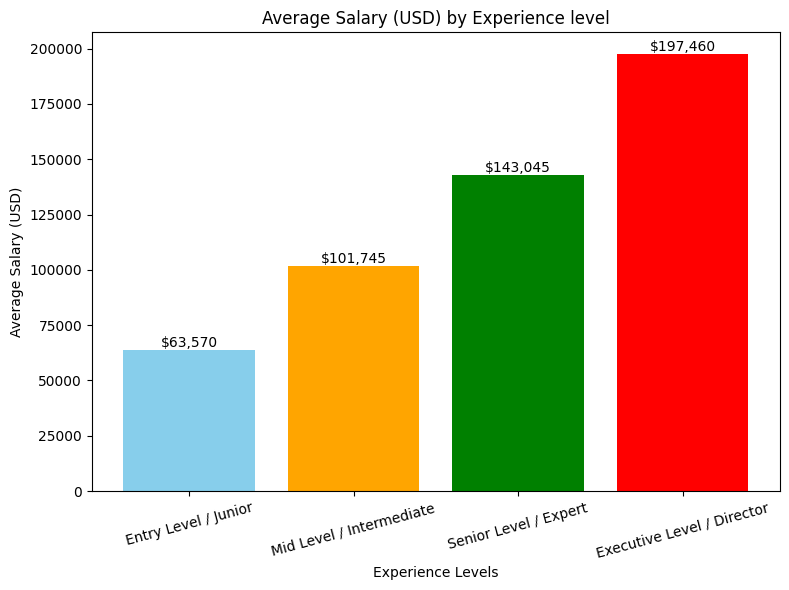

In [15]:
experiences = {'EN':'Entry Level / Junior', 'MI':'Mid Level / Intermediate', 'SE':'Senior Level / Expert', 'EX':'Executive Level / Director'}
exp_avg_salary = (df.groupby('experience_level')['salary_in_usd'].mean().reset_index())

# replace experience level eg.EN -> Entry Level
exp_avg_salary['experience_level'] = (exp_avg_salary['experience_level'].map(experiences))

orders = ['Entry Level / Junior', 'Mid Level / Intermediate', 'Senior Level / Expert', 'Executive Level / Director']
exp_avg_salary['experience_level'] = pd.Categorical(exp_avg_salary['experience_level'], categories=orders, ordered=True)
exp_avg_salary = exp_avg_salary.sort_values('experience_level')
colors = ['skyblue', 'orange', 'green', 'red']

plt.figure(figsize=(8,6))
plt.bar(exp_avg_salary['experience_level'], exp_avg_salary['salary_in_usd'], color=colors)
plt.title('Average Salary (USD) by Experience level')
plt.xlabel('Experience Levels')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=15)
plt.tight_layout()

for x, count in enumerate(exp_avg_salary['salary_in_usd']):
    plt.text(x, count, f"${count:,.0f}", ha='center', va='bottom')
plt.show()

The analysis above indicates that experience level significantly influences the salary of cybersecurity professionals; higher experience levels are associated with higher salaries.

<h3>Average Salary in USD by Countries (top 15 countries)</h3>

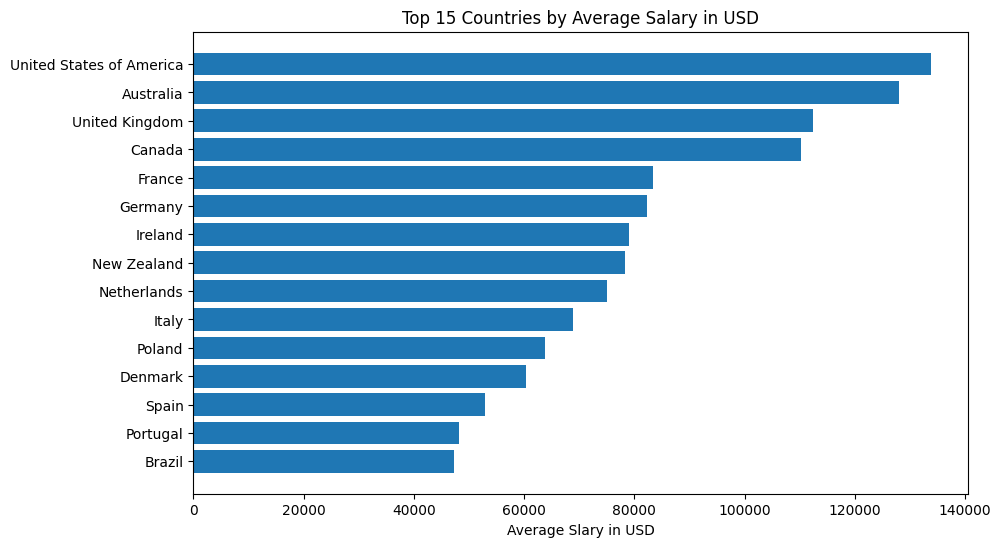

In [16]:
# Feature extraction
# Map country codes with to their long forms
map_country = {"DE": "Germany","US": "United States of America","CY": "Cyprus","BA": "Bosnia and Herzegovina","GB": "United Kingdom","CA": "Canada",
    "ES": "Spain","BR": "Brazil","BW": "Botswana","SG": "Singapore","NL": "Netherlands","IN": "India","AE": "United Arab Emirates","DK": "Denmark",
    "CL": "Chile","AU": "Australia","FR": "France","IT": "Italy","JP": "Japan","GR": "Greece","AZ": "Azerbaijan","RO": "Romania","DZ": "Algeria",
    "AQ": "Antarctica","AX": "Åland Islands","SI": "Slovenia","HR": "Croatia","SE": "Sweden","HU": "Hungary","ET": "Ethiopia","MX": "Mexico","IL": "Israel",
    "IE": "Ireland","PK": "Pakistan","NO": "Norway","PL": "Poland","PT": "Portugal","RU": "Russian Federation","CZ": "Czech Republic","ID": "Indonesia",
    "EE": "Estonia","KE": "Kenya","RS": "Serbia","AR": "Argentina","NZ": "New Zealand","BE": "Belgium","ZA": "South Africa","AT": "Austria",
    "UM": "United States Minor Outlying Islands","LU": "Luxembourg","EG": "Egypt","TW": "Taiwan","VN": "Vietnam","SA": "Saudi Arabia","AF": "Afghanistan",
    "TR": "Turkey"}

df['country_name'] = df['company_location'].map(map_country)
country_avg_salary = (df.groupby('country_name')['salary_in_usd'].agg(avgSalary='mean', count='count').reset_index()) # aggregation "agg()" allows multiple calculations at once
country_avg_salary = country_avg_salary[country_avg_salary['count'] >= 5] # count implies number of employees in the country

# Top 15 countries
top15 = country_avg_salary.sort_values(by='avgSalary', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top15['country_name'], top15['avgSalary'])
plt.title('Top 15 Countries by Average Salary in USD')
plt.xlabel('Average Slary in USD')
plt.gca().invert_yaxis() # gca() - retrives current plotting area (axes) of a figure and invert_yaxis() - flips the vertical axis
plt.show()

Analysis indicates that the United States leads in offering the highest salaries for cybersecurity positions.

<h3>Let us examine the average salary by continent.</h3>

In [17]:
continents = {
     # Europe
    "Germany": "Europe","Cyprus": "Europe","Bosnia and Herzegovina": "Europe","United Kingdom": "Europe","Spain": "Europe","Netherlands": "Europe",
    "Switzerland": "Europe","Denmark": "Europe","France": "Europe","Italy": "Europe","Greece": "Europe","Romania": "Europe","Åland Islands": "Europe",
    "Slovenia": "Europe","Croatia": "Europe","Sweden": "Europe","Hungary": "Europe","Ireland": "Europe","Norway": "Europe","Poland": "Europe","Portugal": "Europe",
    "Czech Republic": "Europe","Estonia": "Europe","Serbia": "Europe","Belgium": "Europe","Austria": "Europe","Luxembourg": "Europe",

    # North America
    "United States of America": "North America","Canada": "North America","Mexico": "North America","United States Minor Outlying Islands": "North America",

    # South America
    "Brazil": "South America","Chile": "South America","Argentina": "South America",

    # Asia
    "India": "Asia","Singapore": "Asia","United Arab Emirates": "Asia","Japan": "Asia","Azerbaijan": "Asia","Israel": "Asia","Pakistan": "Asia",
    "Indonesia": "Asia","Taiwan": "Asia","Vietnam": "Asia","Saudi Arabia": "Asia","Afghanistan": "Asia","Turkey": "Asia",

    # Africa
    "Botswana": "Africa","Algeria": "Africa","Ethiopia": "Africa","Kenya": "Africa","South Africa": "Africa","Egypt": "Africa",

    # Oceania
    "Australia": "Oceania","New Zealand": "Oceania",

    #  Others
    "Antarctica": "Antarctica", "Russian Federation": "Europe / Asia"
}

df['continent'] = df['country_name'].map(continents)
avgSalary_continent = (df.groupby('continent')['salary_in_usd'].agg(avgSalary='mean', count='count').reset_index())

# remove continents with less than 5 countries
avgSalary_continent = avgSalary_continent[avgSalary_continent['count'] >= 5] # here count implies number of countries in a continent
avgSalary_continent = avgSalary_continent.sort_values(by='avgSalary', ascending=False)

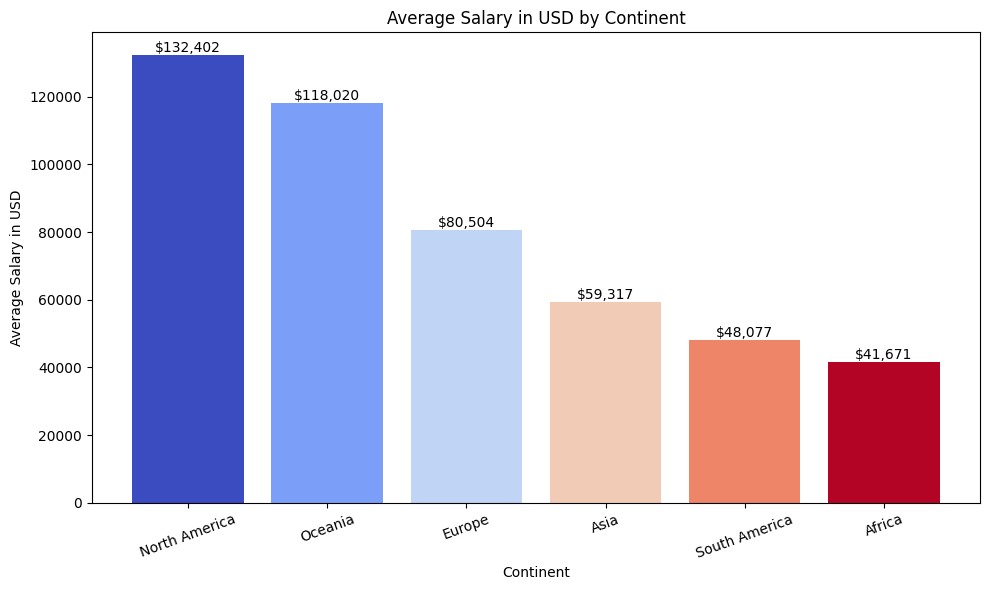

In [18]:
colors = plt.cm.coolwarm(np.linspace(0, 1, len(avgSalary_continent)))

plt.figure(figsize = (10,6))
bars = plt.bar(avgSalary_continent['continent'], avgSalary_continent['avgSalary'], color=colors)
plt.title('Average Salary in USD by Continent')
plt.xlabel('Continent')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=20)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha='center', # center horizontally
        va='bottom' # place text above the bar
    )

plt.tight_layout()
plt.show()

Based on the output, salary distributions can be analyzed to infer relative cost-of-living considerations and to identify high-paying employers by region; the results indicate that North America offers the highest salary levels for security-related job roles.

<h3>Analyzing security jobs</h3>

In [19]:
# Check top 10 high paying security jobs
top15_jobs = (df.groupby('job_title').agg(avg_Salary=('salary_in_usd', 'mean')).reset_index().sort_values(by='avg_Salary', ascending=False).head(15))
top15_jobs

,job_title,avg_Salary
1,Application Security Architect,315000.000000
79,Staff Security Engineer,295000.000000
83,Threat Intelligence Response Analyst,260000.000000
59,Principal Application Security Engineer,237000.000000
77,Software Security Engineer,235540.000000
24,Detection Engineer,232530.846154
44,Information Security Compliance Manager,230000.000000
70,Security Incident Response Engineer,205666.666667
32,Head of Security,194741.833333
39,Incident Response Manager,193923.000000


Above are the top 15 highest-paying roles in the cybersecurity field, with Application Security Architect being the highest-paid position. However, these job titles may not be applicable across all organizations, as compensation is influenced by factors such as company size. Larger organizations particularly in sectors like e-commerce, banks or technology tend to require these specialized security roles to strengthen the company’s overall security posture.

<h3>Average Salary by Job Category</h3>

In [20]:
title = df['job_title'].str.lower().fillna('')

categories = [
    title.str.contains('engineer'),
    title.str.contains('specialist'),
    title.str.contains("head|director|chief"),
    title.str.contains("manager"),
    title.str.contains("consultant"),
    title.str.contains("analyst"),
    title.str.contains("architect"),
    title.str.contains("researcher"),
    title.str.contains("penetration|ethical hacker|offensive"),
]

choices = ["Engineer", "Specialist", "Executive", "Manager", "Consultant", "Analyst",
    "Architect", "Researcher", "Offensive Security"]
df['job_category'] = np.select(categories, choices, default="Other")

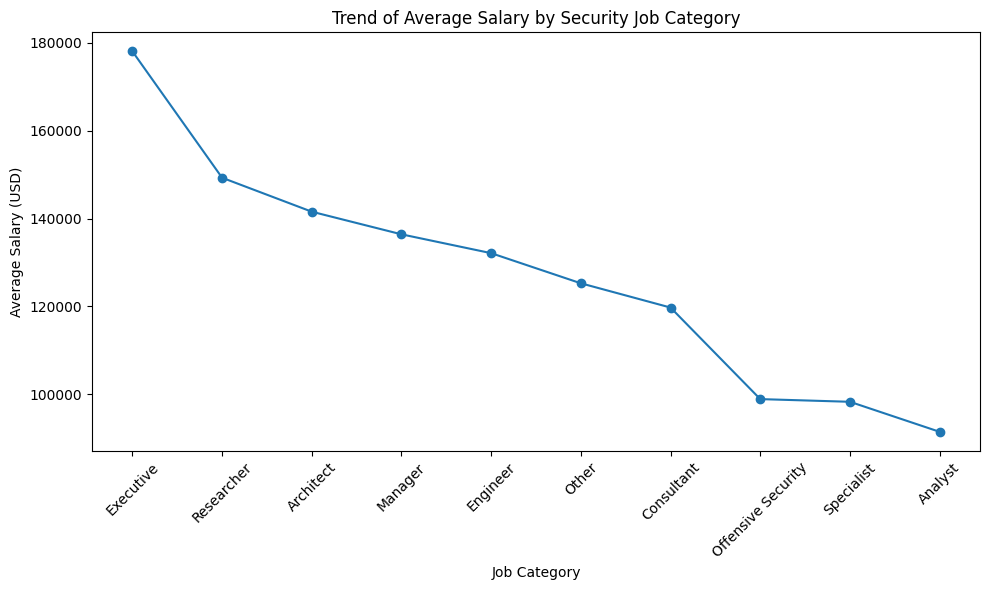

In [21]:
category_avgsalary = (df.groupby('job_category')['salary_in_usd'].mean().reset_index().sort_values(by='salary_in_usd', ascending=False))

# Plot
plt.figure(figsize=(10,6))
plt.plot(category_avgsalary['job_category'], category_avgsalary['salary_in_usd'], marker='o')
plt.title('Trend of Average Salary by Security Job Category')
plt.xlabel('Job Category')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This analysis of cybersecurity salaries using the [Cyber_salaries](https://www.kaggle.com/datasets/whenamancodes/infoseccyber-security-salaries/data) dataset provides insights into which security roles to prioritize, given the wide variety of job titles. It also allows professionals to target positions within specific companies and countries while understanding the associated average compensation. Additionally, cybersecurity professionals can leverage experience to increase their marketability, which typically translates to higher salaries.

### Distribution of 'salary_in_usd' using histplot

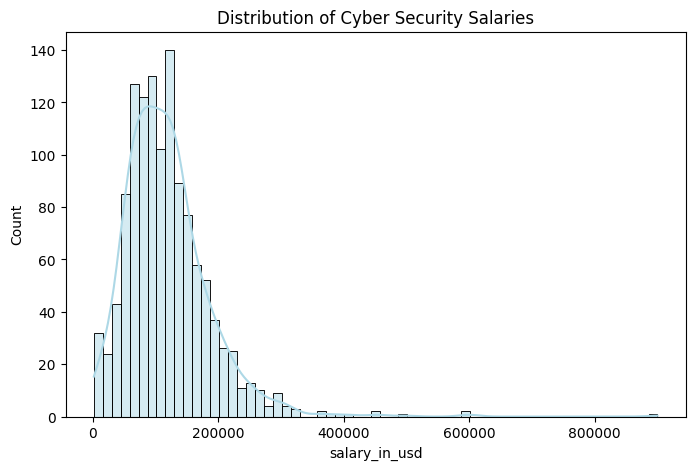

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='salary_in_usd', kde=True, color='lightblue')
plt.title("Distribution of Cyber Security Salaries")
plt.show()

The *salary_in_usd* distribution is right-skewed, meaning the mean is greater than the median due to the long tail on the higher end. Most salaries are clustered at the lower end, with relatively few high-value salaries stretching the right tail.

### Check for Outliers

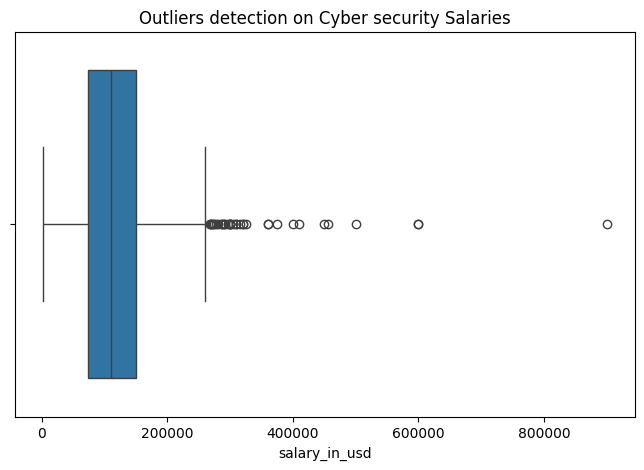

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['salary_in_usd'])
plt.title('Outliers detection on Cyber security Salaries')
plt.show()

The boxplot indicates the presence of outliers, with some representing unusually high salaries in USD

### Handling Outliers on Numerical features

In [24]:
numeric_colmn = df.select_dtypes(include=[np.number])

Q1 = numeric_colmn.quantile(0.25)
Q3 = numeric_colmn.quantile(0.75)
IQR = Q3 - Q1

df = df[~((numeric_colmn < (Q1 - 1.5 * IQR)) | (numeric_colmn > (Q3 + 1.5 * IQR))).any(axis=1)]

In [25]:
!pip install pycountry
!pip install pycountry_convert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 17.7 MB/s eta 0:00:00


In [26]:
# Convert Country code (ISO-2) to continent in "employee_residence' and 'company_location' columns
import pycountry
import pycountry_convert as pc

def countrycode(code):
    try:
        country = pycountry.countries.get(alpha_2=code)
        if country is None:
            return "Other"

        country_alpha2 = country.alpha_2
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)

        return continent_name
    except:
        return "Other"


# Apply transformation to both columns
df["employee_residence"] = df["employee_residence"].apply(countrycode)
df["company_location"] = df["company_location"].apply(countrycode)

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,country_name,continent,job_category
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,Europe,100,Europe,S,Germany,Europe,Other
1,2022,SE,FT,Security Officer,123400,USD,123400,North America,0,North America,M,United States of America,North America,Other
2,2022,SE,FT,Security Officer,88100,USD,88100,North America,0,North America,M,United States of America,North America,Other
3,2022,SE,FT,Security Engineer,163575,USD,163575,North America,100,North America,M,United States of America,North America,Engineer
4,2022,SE,FT,Security Engineer,115800,USD,115800,North America,100,North America,M,United States of America,North America,Engineer


In [27]:
print(df["employee_residence"].value_counts())
print(df["company_location"].value_counts())

employee_residence
North America    865
Europe           216
Asia              27
Oceania           23
South America     12
Africa             8
Name: count, dtype: int64
company_location
North America    882
Europe           211
Oceania           23
Asia              17
South America     11
Africa             6
Other              1
Name: count, dtype: int64


In [28]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size', 'country_name',
       'continent', 'job_category'],
      dtype='object')

In [29]:
# drop unnecessary columns
df = df.drop(columns=['country_name', 'job_title', 'work_year', 'salary', 'salary_currency', 'continent'])

# Modelling and Evaluation

In [30]:
from sklearn.model_selection import train_test_split

X =  df.drop('salary_in_usd', axis=1) # independent variable
y = np.log1p(df['salary_in_usd']) # dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Encoding Categorical Columns

In [32]:
# Encoding Ordinal Columns
exp_ordEncoder = OrdinalEncoder()
emptype_ordEncoder = OrdinalEncoder()
compsize_ordEncoder = OrdinalEncoder()

# Train set
X_train['experience_level'] = exp_ordEncoder.fit_transform(X_train[['experience_level']])
X_train['employment_type'] = emptype_ordEncoder.fit_transform(X_train[['employment_type']])
X_train['company_size'] = compsize_ordEncoder.fit_transform(X_train[['company_size']])

# Test set
# Ordinal Columns
X_test['experience_level'] = exp_ordEncoder.fit_transform(X_test[['experience_level']])
X_test['employment_type'] = emptype_ordEncoder.fit_transform(X_test[['employment_type']])
X_test['company_size'] = compsize_ordEncoder.fit_transform(X_test[['company_size']])

# Saving the encoders
joblib.dump(exp_ordEncoder,'experience_encoder.pkl')
joblib.dump(emptype_ordEncoder,'emptype_encoder.pkl')
joblib.dump(compsize_ordEncoder,'compsize_encoder.pkl')

# Label Encoding
jobcategory_encoder = LabelEncoder()
X_train['job_category'] = jobcategory_encoder.fit_transform(X_train['job_category'])
X_test['job_category'] = jobcategory_encoder.fit_transform(X_test['job_category'])

# Saving label encoder
joblib.dump(jobcategory_encoder, "job_category_encoder.pkl")

# Onehot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [33]:
# Save feature columns after get_dummies
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

# Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=12,          # controls overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [35]:
pred_rf = rf.predict(X_test)

# convert back from log scale
ytest_normal = np.expm1(y_test)
preds_normal = np.expm1(pred_rf)

# RandomForest model evaluation (evaluation metrics)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_rmse = np.sqrt(mean_squared_error(ytest_normal, preds_normal))
rf_mae = mean_absolute_error(ytest_normal, preds_normal)
r2score = r2_score(ytest_normal, preds_normal)

# results
print('RandomForest Metrics Performance')
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", r2score)

RandomForest Metrics Performance
RMSE: 39172.18528421489
MAE: 29706.33028753209
R2 Score: 0.4150921066877564


# GradientBoostingRegressor

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators =200,
    learning_rate =0.03,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, n_estimators=200, random_state=42)

In [37]:
# Predict
pred_gbr = gbr.predict(X_test)

y_test_normal = np.expm1(y_test)
pred_normal = np.expm1(pred_gbr)

# Metrics
gbr_rmse = np.sqrt(mean_squared_error(y_test_normal, pred_normal))
gbr_mae = mean_absolute_error(y_test_normal, pred_normal)
r2 = r2_score(y_test_normal, pred_normal)

# Print results
print("GradientBoosting Metrics Performance")
print("RMSE:", gbr_rmse)
print("MAE:", gbr_mae)
print("R2 Score:", r2)

GradientBoosting Metrics Performance
RMSE: 39240.335752105755
MAE: 30164.630502633743
R2 Score: 0.41305512961411517


# XGBRegressor

In [38]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=900,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",
    early_stopping_rounds=100
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

In [39]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.02, 0.03],
    'subsample': [0.75, 0.85, 0.95],
    'colsample_bytree': [0.75, 0.85, 0.95],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method="hist"),
    param_grid,
    n_iter=25,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_
print("Best Params:", search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params: {'subsample': 0.95, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


In [40]:
pred_xgb = best_xgb.predict(X_test)

# Convert back to normal salary scale
y_test_normal = np.expm1(y_test)
pred_normal = np.expm1(pred_xgb)

xgb_rmse = np.sqrt(mean_squared_error(y_test_normal, pred_normal))
xgb_mae = mean_absolute_error(y_test_normal, pred_normal)
xgb_r2 = r2_score(y_test_normal, pred_normal)

print("XGBoost Metrics Performance")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2 Score:", xgb_r2)

XGBoost Metrics Performance
RMSE: 37372.60435255422
MAE: 28842.57282366072
R2 Score: 0.4675993113992034


In [41]:
joblib.dump(best_xgb, "xgb_model.pkl")

['xgb_model.pkl']

Among the three evaluated models, **_XGBRegressor_** achieved the best performance, producing the lowest RMSE and MAE and average R2 Score, indicating moderate predictive capability and good generalization. Hyperparameter tuning further improved the XGBoost model, slightly reducing prediction errors and confirming that optimized parameters enhance model accuracy. Therefore, the tuned **_XGBRegressor_** was selected as the reliable model for this prediction task due to its overall performance compared to _Random Forest_ and _GradientBoosting_.